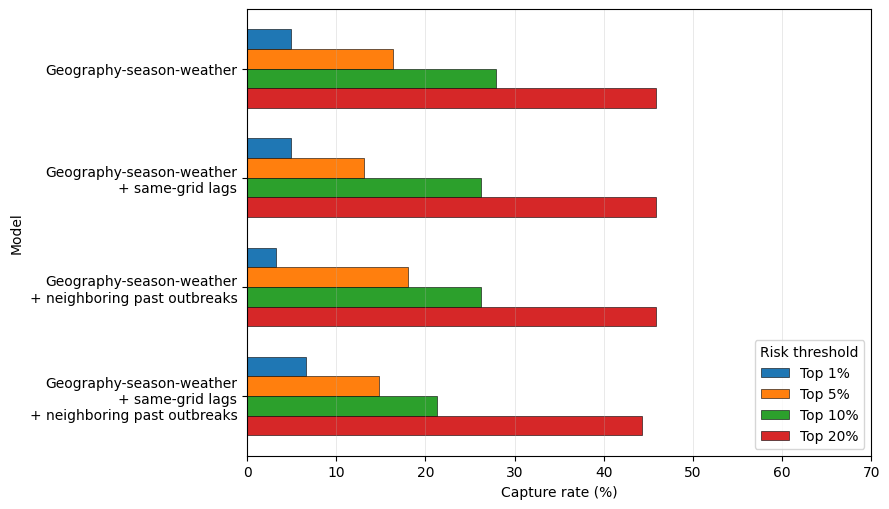

Using: 06_v2_rolling_pooled_summary_previous_week_weather.csv
Saved: figure1_topk_capture_rates_previous_week_weather_horizontal.png
Saved: figure1_topk_capture_rates_previous_week_weather_horizontal.pdf


,model_name,total_events,top1_capture_rate,top5_capture_rate,top10_capture_rate,top20_capture_rate
0,geo_season_previous_week_weather,61,0.049180,0.163934,0.278689,0.459016
1,geo_season_previous_week_weather_same_grid_lags,61,0.049180,0.131148,0.262295,0.459016
2,geo_season_previous_week_weather_neighbor_past,61,0.032787,0.180328,0.262295,0.459016
3,geo_season_previous_week_weather_lags_neighbor...,61,0.065574,0.147541,0.213115,0.442623


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Figure 1: Pooled Top-k capture rates by rolling model
# Previous-week weather version
# Horizontal grouped bar chart without numeric labels
# ============================================================

candidate_paths = [
    Path(
        "/content/drive/MyDrive/avian_influenza_project/"
        "processed/model_outputs_riskmap_eval/"
        "06_v2_rolling_pooled_summary_previous_week_weather.csv"
    ),
    Path(
        "06_v2_rolling_pooled_summary_previous_week_weather.csv"
    ),
]

input_path = next(
    (path for path in candidate_paths if path.exists()),
    None,
)

if input_path is None:
    raise FileNotFoundError(
        "Updated rolling summary was not found.\n"
        "Run "
        "06_v2_rolling_riskmap_evaluation_previous_week_weather_final.ipynb "
        "first.\nChecked:\n"
        + "\n".join(str(path) for path in candidate_paths)
    )

summary = pd.read_csv(input_path)

model_order = [
    "geo_season_previous_week_weather",
    "geo_season_previous_week_weather_same_grid_lags",
    "geo_season_previous_week_weather_neighbor_past",
    "geo_season_previous_week_weather_lags_neighbor_past",
]

model_labels = {
    "geo_season_previous_week_weather": "Geography-season-weather",
    "geo_season_previous_week_weather_same_grid_lags": (
        "Geography-season-weather\n+ same-grid lags"
    ),
    "geo_season_previous_week_weather_neighbor_past": (
        "Geography-season-weather\n+ neighboring past outbreaks"
    ),
    "geo_season_previous_week_weather_lags_neighbor_past": (
        "Geography-season-weather\n+ same-grid lags\n+ neighboring past outbreaks"
    ),
}

required_cols = {
    "model_name",
    "total_events",
    "top1_capture_rate",
    "top5_capture_rate",
    "top10_capture_rate",
    "top20_capture_rate",
}
missing = required_cols - set(summary.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

summary = (
    summary.set_index("model_name")
    .reindex(model_order)
    .reset_index()
)

if summary["model_name"].isna().any():
    raise ValueError("One or more required rolling models are missing.")

if not summary["total_events"].eq(61).all():
    raise ValueError(
        "Each model must contain 61 pooled outbreak events.\n"
        f"{summary[['model_name', 'total_events']]}"
    )

topk = [1, 5, 10, 20]
rate_columns = [f"top{k}_capture_rate" for k in topk]

y = np.arange(len(model_order))
height = 0.18

fig, ax = plt.subplots(figsize=(9.0, 5.2))

for index, (k, column) in enumerate(zip(topk, rate_columns)):
    offset = (index - (len(topk) - 1) / 2) * height
    values = summary[column].to_numpy() * 100.0

    ax.barh(
        y + offset,
        values,
        height=height,
        label=f"Top {k}%",
        edgecolor="black",
        linewidth=0.4,
    )

ax.set_yticks(y)
ax.set_yticklabels(
    [model_labels[model] for model in model_order],
    fontsize=10,
)
ax.set_xlabel("Capture rate (%)")
ax.set_ylabel("Model")
ax.set_xlim(
    0,
    max(70, float(summary[rate_columns].max().max() * 100 + 8)),
)
ax.grid(axis="x", linewidth=0.4, alpha=0.5)
ax.invert_yaxis()

ax.legend(
    title="Risk threshold",
    loc="lower right",
    frameon=True,
)

plt.tight_layout()

output_dir = input_path.parent
png_path = output_dir / "figure1_topk_capture_rates_previous_week_weather_horizontal.png"
pdf_path = output_dir / "figure1_topk_capture_rates_previous_week_weather_horizontal.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Using:", input_path)
print("Saved:", png_path)
print("Saved:", pdf_path)
display(summary[["model_name", "total_events"] + rate_columns])